---
title: Simulation
jupyter: python3
execute:
  cache: true
---

## Random Variables {#sec-07-top}

In statistics, we use random variables to describe the probabilistic behaviour
of phenomenon. Random variables are real numbers that represent the phenomena we
observe. For instance, we might let $X$ represent a coin toss, with $X=1$
representing Heads and $X=0$ representing Tails.

Random variables come with a rule (or function) that prescribes the
probabilities with which it takes on particular values. For instance, if we had
a fair coin, then the rule would be that
$$
P(X=1) = P(X=0) = \frac{1}{2}
$$

On the other hand, a biased coin might follow the rule
$$
P(X=1) = \frac{2}{3},\quad P(X=0) = \frac{1}{3}
$$

This rule tells us which events are more likely, and which are less likely.

In [1]:
from math import pi 
import pprint

import mesa

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk import word_tokenize

from numpy.random import default_rng
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import binom, bernoulli, norm, expon, uniform

### Discrete Random Variables

Discrete random variables take on only a countable number of values. Examples are:

* A coin toss ($\{0, 1\}$)
* The number of taxis passing by a particular junction between 12noon and 1pm. 
  ($\{0, 1, 2, \ldots, \}$)
* The number of coin tosses until we observe Heads. ($\{1, 2, 3, \ldots, \}$)

Discrete random variables are defined by their probability mass function (pmf),
which is just a table or a function describing $P(X=i)$ for all possible $i$
values. Once we know the pmf of a random variable, we know everything about it
- the mean, variance, quantiles, maximum values, etc.

We can visualise a pmf using a bar-chart. Here is the pmf for the above biased
coin.

In [ ]:
#| fig-align: center
plt.figure(figsize=(5,3))
plt.bar([0,1], [1/3, 2/3], tick_label=['0', '1'], width=0.3);
plt.xlim(-1,2); 
plt.ylim(0,1); 
plt.title('pmf of \'X\' random variable' );

Here is the pmf for a random variable representing the total number of Heads
after 10 tosses of that same coin. Suppose we call that new random variable
$Y$.

In [ ]:
#| fig-align: center
plt.figure(figsize=(5,3))
probs = binom.pmf(np.arange(0, 11), n=10, p=2/3)
plt.bar(np.arange(0, 11), probs);plt.ylim(0,1);
plt.title('pmf of no. of coin tosses');

If we wish to find the probability of events, for instance, $P(Y \le 4)$, we
sum up the heights of the bars.

### Continuous Random Variables

Continuous random variables are defined by what is known as a probability
density function. Continuous random variables can take on an uncountable number
of values, for instance, all real numbers in the interval $[0,1]$.

In [ ]:
#| fig-align: center
#| fig-cap: "Continuous random variables"
#| label: fig-cts-rv
x = np.linspace(-3, 3, num=100)
y = norm.pdf(x)
plt.figure(figsize=(8,3), facecolor='0.9')
plt.subplot(131)
plt.plot(x,y)
plt.ylim(0,1)
plt.title('Normal pdf')

y = expon.pdf(x[x>0])
plt.subplot(132)
plt.plot(x[x>0],y)
plt.ylim(0,1)
plt.title('Exponential pdf');

x = np.linspace(0, 1, num=100)
y = uniform.pdf(x)
plt.subplot(133)
plt.plot(x,y)
plt.ylim(0,1.1)
plt.title('Uniform pdf');

@fig-cts-rv shows three common continuous random variables: Normal, Exponential and 
Uniform.

### Generating Random Variates

With a computer, we can generate random variables from almost any distribution.
There are built-in routines to generate from the 'named' distributions. For
instance,

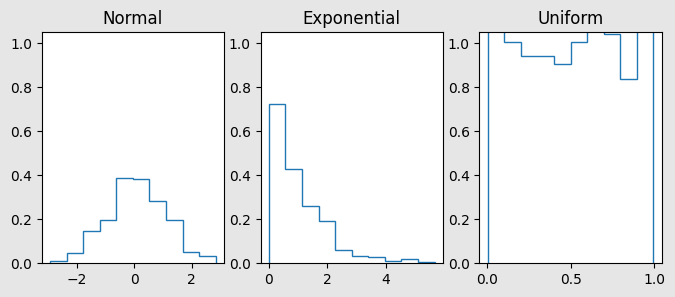

In [44]:
#| fig-align: center
#| fig-cap: "Histogram of random variables"
#| label: fig-cts-hist
rng = default_rng(5003)

yvals = np.zeros((3,300))
yvals[0,:] = rng.normal(size=300)
yvals[1,:] = rng.exponential(size=300)
yvals[2, :] = rng.uniform(size=300)
pdfs = ['Normal', 'Exponential', 'Uniform']
plt.figure(figsize=(8,3), facecolor='0.9')

for i in np.arange(0,3):
    plt.subplot(1, 3, i+1)
    plt.hist(yvals[i,:], density=True, histtype='step')
    plt.title(pdfs[i])
    plt.ylim(0, 1.05)

Notice how, in @fig-cts-hist, the (normalised) histograms look a lot like the
corresponding pdfs.

## General Principles in Simulation Studies

### Introduction

The objective of any simulation study is to estimate an expectation $E(X)$.
Simulation studies involve the use of a computer to generate independent copies 
of the random variable of interest $X$. Here are a couple of examples where 
simulation studies would be applicable. 

Through the estimation of $E(X)$, simulation studies allow us to:

1. Consider different planning scenarios and estimate the throughput from them.
2. Study the emergent behaviour of complex situations.

::: {#exm-insurance-1 style="background-color: #D5D1D164; padding: 20px"}
### Insurance claims
\index{Insurance!Description}

Before the financial year begins, an insurance company has to decide how much
cash to keep, in order to pay out the claims for that year. Suppose that 
claims are independent of each other and are distributed as $Exp(1/200)$
dollars. This means that the probability density function (pdf) of the random 
variable is $f_X(x) = \frac{1}{200} \exp(-x/200),\; x > 0$

Also suppose that the number of claims in a year is a Poisson random variable with mean 8.2. 

An actuary has been asked to determine the size of the reserve fund that should
be set up, and he recommends $12,000. We might consider answering the following
question using simulation: 

* What is the probability that the total claims will exceed the reserve fund?

If we let $Y$ be the random variable representing the total sum of claims, we
are interested in estimating $P(Y > 12000)$. Since probabilities are expectations,
we can use simulation to estimate this value.

:::

<br>

Here is a slightly more sophisticated example.

::: {#exm-sandwich-1 style="background-color: #D5D1D164; padding: 20px"}
### Sandwich Shop Closing Time
\index{Sandwich!Description}

Suppose that you run a sandwich shop, which is open from 9am till 5pm. Your
philosophy has always been to serve every customer who has entered before 5pm,
even if that requires you to stay back until they have been served. You
would like to estimate the mean amount of overtime you have to work.

If you are willing to assume that the inter-arrival times of customers is 
$Exp(3)$ hours, then it is possible to simulate this process to estimate the 
mean time that you would have to remain open, beyond 5pm.

:::

### Steps in a Simulation Study

The two examples above are known as Discrete Event Simulations. It is one type
of simulation study.  Another type of simulations are Agent-Based Models. No
matter the type of simulation, the basic steps in a simulation study are:

1. Identify the random variable of interest and write a program to simulate it.
2. Generate an iid sample $X_1, X_2, \ldots, X_n$ using this program.
3. Estimate $E(X)$ using $\bar{X}$.

Before proceeding, let us refresh our knowledge of the properties of the sample mean.

### Theory

There are two important theorems that simulation studies rely on. The first 
is the Strong Law of Large Numbers (SLLN).

#### Strong Law of Large Numbers

If $X_1, X_2, \ldots, X_n$ are independent and identically distributed with 
$E(X) < \infty$, then 
$$
\bar{X} =\frac{1}{n} \sum_{i=1}^n X_i\rightarrow E(X) \quad \text{with probability 1.}
$$


In the simulation context, it means that as we generate more and more samples
(i.e. increase $n$), our sample mean $\bar{X}$ converges to the desired value 
$E(X)$, *no matter what the distribution of $X$ is.*

The second theorem that aids us is the Central Limit Theorem (CLT).

#### Central Limit Theorem

Let $X_1, X_2, \ldots, X_n$ be i.i.d., and suppose that 

*  $-\infty < E(X_1) = \mu < \infty$. 
* $Var(X_1) = \sigma^2 < \infty$.

Then 
$$
\frac{\sqrt{n} (\bar{X} - \mu)}{\sigma} \Rightarrow N(0,1)
$$
where $\Rightarrow$ denotes convergence in distribution.

This is sometimes informally interpreted to mean that when $n$ is
large, $\bar{X}$ is approximately Normal with mean $\mu$ and variance
$\sigma^2/n$. In the simulation context, we can use this theorem to obtain a
confidence interval for the expectation that we are estimating.

Also take note of the following properties of the sample mean and variance:

#### Sample Estimates

It can be shown that both the sample mean and sample standard deviation are 
unbiased estimators.
$$
E(\bar{X}) = E(X), \quad E(s^2) = \sigma^2
$$
where $s^2 = \frac{\sum (X_i - \bar{X})^2}{n-1}$.

To obtain a $(1-\alpha)100%$ confidence interval for $\mu$, we use the following 
formula, from the CLT:

$$
\bar{X} \pm z_{1-\alpha/2} \frac{s}{\sqrt{n}}
$$

When our goal is to estimate a probability $p$, we have to introduce a
corresponding indicator variable $X$ such that 

$$
X = 
\begin{cases}
1 & \text{with probability $p$} \\
0 & \text{with probability $1- p$}
\end{cases}
$$

In this case, the formula for the CI becomes 
$$
\bar{X} \pm z_{1-\alpha/2} \sqrt{\frac{\bar{X}(1-\bar{X})}{n}}
$$

## Object-Oriented Programming in Python

Python has been developed as both a functional and object-oriented programming
language. Much of the code we will soon use for the mesa package involves
creation of an instance, and then accessing the attributes (data or methods) of
that instance.

The syntax for *defining* a class is:

```
class ClassName:
    <statement-1>
    .
    .
    <statement-N>
```

A class definition typically consists of function definitions and attributes. A
special function within a class definition, `__init__()`, can be used to set
the initial state of *instances* of a class. Think of a class definition as a
template, and instances as copies made using that template.

Consider the following class Circle.

In [ ]:
class Circle:
    """ A simple class definition 
    
    c0 = Circle()
    c0.radius
    
    """
    def __init__(self, radius = 1.0):
        self.radius = radius
        
    def area(self):
        """ Compute area of circle"""
        return pi*(self.radius**2)

We can create multiple circles using this template. Note the use of the keyword `self` to refer to attributes of the instance.

In [ ]:
c1 = Circle(3.2)
c2 = Circle(4.0)

print(f"""
The radius of c1 is {c1.radius} and the radius of c2 is {c2.radius}.
The area of c1 is {c1.area():.3f} and the area of c2 is {c2.area():.3f}.
""")

## Introduction to Agent Based Models

Agent-based models (ABM) consist of individual elements (agents) interacting
with one another. One of the most common uses of an agent-based model is to
understand how the behaviour of the system, as a whole, emerges from simple
rules for the agents' and their interactions. A very famous example is from the
simulation software used to create battle scenes in The Lord of The Rings
movies from the early 2000s. 

::: {.content-visible when-format="html"}
The following video was from an 
[article on the MASSIVE software](https://www.cnet.com/culture/entertainment/features/how-lord-of-the-rings-used-ai-to-change-big-screen-battles-forever/).

{{< video data/lotr.mp4 aspect-ratio="4x3" align="center">}}
:::

::: {.content-visible when-format="pdf"}
Take a look at the video from an 
[article on the MASSIVE software](https://www.cnet.com/culture/entertainment/features/how-lord-of-the-rings-used-ai-to-change-big-screen-battles-forever/).

:::

Today, ABM are used in scenarios where the overall behaviour of a system is to
complicated to predict by modeling the stages of interaction. Examples of these
scenarios are:

1. COVID-19 modeling,
2. Modeling of driver behaviour on roads for the purpose of understanding traffic,
3. Modeling of swarms, e.g. locusts, fish, etc, and
4. Modeling of effects of networks in marketing and in organisations.

The essential characteristics of an ABM are the following:

1. Agents at various scales,
2. Agents make decisions, based on defined behaviours
3. Agents interact with one another in time and possibly space.

Remember that our role as analysts is to imbue the agents with the appropriate
traits (behaviours), interactions and probabilities. Otherwise, our model is
not going to yield useful results.

### Introduction to Mesa

Mesa is a Python package for running simulations using Agent-Based Models (ABM).
Before we proceed, here are a few overarching concepts about this framework:

1. *Agents* are defined using classes. Within the class definition for an agent, we need to define:
    * how the agent is initialised,
    * what the agent does at each time-step.
2. The *model* is defined as a class as well. The model constitutes agents
   (defined through the class(es) above) and a *scheduler* that determines the
   sequence in which agents act, and the space in which they act.

Mesa also comes equipped with data collection tools to extract information from
agents and/or the model at each step of the scheduler. Both the agent and the
model classes should define a `step()` method. In ABM, a *step* is the smallest
unit of time. It is also sometimes referred to as a "tick".

::: {#exm-boltzmann-1 style="background-color: #D5D1D164; padding: 20px"}
### Boltzmann model overview
\index{Boltzmann Model!Overview}

This is a simple model from social sciences, to demonstrate the use of mesa for
agent-based modeling. In this agent-based economy, the assumptions are:

1. There are a certain number of agents.
2. All agents begin with 1 unit of money.
3. At every step of the model, an agent gives 1 unit of money (if they have it), to another, randomly chosen, agent.

Before we begin the model, think about what you expect to see at the end of the 
simulations. The reference for this paper is @dragulescu2002statistical.

:::

## Agent and Model Classes (v1)

The code below contains our initial definition for the agent class. The
initialisation simply consists of setting the wealth for the agent. The `step`
method defines that the agent will pick an agent (possibly itself) and transfer
1 unit of money to that agent.

In [2]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        # Pass the parameters to the parent class.
        super().__init__(model)

        # Create the agent's variable and set the initial values.
        self.wealth = 1

    def step(self):
        # Verify agent has some wealth
        if self.wealth > 0:
            #other_agent = self.random.choice(self.model.agents)
            other_agent = self.rng.choice(self.model.agents)
            # print(other_agent.unique_id)
            other_agent.wealth += 1
            self.wealth -= 1

class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, N, rng=None):
        super().__init__(rng=rng)
        self.num_agents = N
        #self.seed = 5003

        # Create agents
        MoneyAgent.create_agents(model=self, n=N)
        # for i in range(self.num_agents):
        #    a = MoneyAgent(self)

    def step(self):
        """Advance the model by one step."""
        self.agents.shuffle_do("step")

In [3]:
rng2 = default_rng(530)
all_wealth = []
model = MoneyModel(N=10, rng=rng2)

In [4]:
for i in range(2):
    model.step()

# Extract the results
# for agent in model.schedule.agents:
for agent in model.agents:
    all_wealth.append(agent.wealth)
    
prop = (np.array(all_wealth) == 0).mean()
print(f"The proportion of agents with zero wealth is {prop:.3f}.")

The proportion of agents with zero wealth is 0.400.


::: {#exm-boltzmann-2 style="background-color: #D5D1D164; padding: 20px"}
### Boltzmann model simple execution
\index{Boltzmann Model!v1 simple execution}

The next cell creates a model with 10 agents, and runs the model for 100 steps.
At the end of this run, we compute the proportion of customers with wealth 0.
This is a simple initial metric that we define on the model. Once again, just as
with the parameters of the model, the metrics we extract determine how well we
can use the model.

Remember that, to begin with, all agents had equal wealth. If this proportion is
high, it indicates a severe imbalance in wealth distribution after 100 time
steps.


In [29]:
rng2 = default_rng(53)
all_wealth = []
model = MoneyModel(N=10, rng=rng2)

In [18]:
model.rng.choice([0,3, 45], size=5, replace=True)

array([ 3,  3,  0,  0, 45])

In [8]:
# allows replicability of results; useful for debugging
rng=default_rng(5003)
model.reset_rng(rng) 

In [36]:
for i in range(100):
    model.step()

# Extract the results
# for agent in model.schedule.agents:
for agent in model.agents:
    all_wealth.append(agent.wealth)
    
prop = (np.array(all_wealth) == 0).mean()
print(f"The proportion of agents with zero wealth is {prop:.3f}.")

The proportion of agents with zero wealth is 0.443.


:::

### Data Collection

However, remember that when we perform simulations, we need to repeat the run
multiple times, take the average, and then form a confidence interval. To
prepare the mesa model to perform data collection, we write a function that,
given a model, will compute the proportion of zero-wealth agents.

In [5]:
def compute_zero_prop(mesa_model):
    all_wealth = []
    # Extract the results
    for agent in mesa_model.agents:
        all_wealth.append(agent.wealth)
    prop = (np.array(all_wealth) == 0).mean()
    return prop

compute_zero_prop(model)

np.float64(0.4)

Next, we update the model class to define a data collector that calls the
`compute_zero_prop()` function that we just defined. With Mesa, the data
collector can be based on the model, or it could be a function that operates on
individual agents.

In [6]:
# How many agents are in the model?
print(f"Total agents: {len(model.agents)}")

Total agents: 10


In [7]:
# Iterate over agents (just the first 5 for brevity)
for agent in model.agents.select():
    print(
        f"  Agent {agent.unique_id}: wealth={agent.wealth}"
    )

  Agent 1: wealth=0
  Agent 2: wealth=1
  Agent 3: wealth=1
  Agent 4: wealth=3
  Agent 5: wealth=1
  Agent 6: wealth=0
  Agent 7: wealth=0
  Agent 8: wealth=0
  Agent 9: wealth=1
  Agent 10: wealth=3


In [8]:
class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, N, rng=None):
        super().__init__(rng=rng)
        self.num_agents = N

        # Create agents
        MoneyAgent.create_agents(model=self, n=N)

        self.datacollector = mesa.DataCollector(
            model_reporters={"zero_prop": compute_zero_prop}
        )

    def step(self):
        self.agents.shuffle_do("step")
        # Collect data at every step
        self.datacollector.collect(self)

::: {#exm-boltzmann-3 style="background-color: #D5D1D164; padding: 20px"}
### Boltzmann model data collection
\index{Boltzmann Model!v1 data collection}

Once again, we reset the seed and re-run the model. We can then retrieve the
zero-wealth proprortion at *every step of the model*.

In [15]:
model = MoneyModel(N=10, rng=3)
#model.reset_rng(5003)
#model.reset_randomizer(seed=5003)

for i in range(100):
    model.step()
    
df_output = model.datacollector.get_model_vars_dataframe()
df_output.head()

,zero_prop
0,0.5
1,0.4
2,0.4
3,0.3
4,0.3


Take note that this is considered *a single simulation*. Any simulation model
requires time to reach an equilibrium phase. In this case, we are interested in
measuring the average proportion of zeros after 100 time steps. To do so, we
need to run several simulations, compute the zero-wealth proportion at each step
and take the average.

:::

## Multiple Iterations

The mesa package has features to help us to run multiple simulations and then to
collate the results. The primary method is `.batch_run()`. 

::: {#exm-boltzmann-4 style="background-color: #D5D1D164; padding: 20px"}
### Boltzmann model multiple iterations
\index{Boltzmann Model!v1 multiple iterations}

In this example, we shall run the model for *50 iterations*. Remember that each
iteration consists of a fresh set of 100 time steps.

  0%|          | 0/50 [00:00<?, ?it/s]

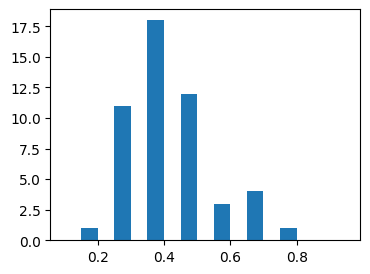

In [16]:
#| fig-align: center
params = {"N": 10}

results = mesa.batch_run(
    MoneyModel,
    parameters=params,
    rng=[None]*50,
    max_steps=100,
    number_processes=1,
    data_collection_period=-1
    #display_progress=True,
)
results_df = pd.DataFrame(results)
results_df.zero_prop.hist(grid=False, 
                          bins=np.arange(0.10, 1.00, 0.05),
                          figsize=(4,3));

We can see that the proportion of agents with zero income is considerably higher
than the 0.0 that the population began with.

In [17]:
ttest_out = stats.ttest_1samp(results_df.zero_prop, 0.0).confidence_interval()
print(f"""
The 95% CI for the mean proportion of agents with zero income is
({ttest_out[0]:.3f}, {ttest_out[1]:.3f})
       """)


The 95% CI for the mean proportion of agents with zero income is
(0.405, 0.479)
       


:::

## Agent and Model Classes (v2)

### Assessment of Income Inequality

The Gini coefficient is a common measure of the income inequality of a
population. The Gini coefficient can be defined using a Lorenz curve for a
population (see @fig-lorenz).

![Lorenz curve](figs/Economics_Gini_coefficient2.svg.png){#fig-lorenz fig-align=center width=50%}

The x- and y-axes both run from 0 to 100%. The x-axis depicts the cumulative
proportion of a population (increasing from left to right), ranked by income.
The y-axis depicts the cumulative proportion of total income earned by the
population. If all members earned an equal amount, the Lorenz curve would be a
straight line, from bottom left to top right. Gini coefficient measures
deviation from this equality as:

$$
\frac{A}{A+B}
$$

The Gini coefficient is a measure between 0 and 1. A value of 0 indicates income
equality, while a value of 1 indicates that only 1 member of the population
earns all the income (extreme inequality). 

::: {.content-visible when-format="pdf"}
The online version of our textbook contains an interactive visualisation, from
[Our World In Data](https://ourworldindata.org/grapher/economic-inequality-gini-index?tab=map), 
on how Gini coefficients around the world have evolved over time.
::: 

::: {.content-visible when-format="html"}
Here is an interactive visualisation from Our World in Data on Gini coefficient
values around the world, across time.

```{=html}
<iframe width="780" height="500" src="https://ourworldindata.org/grapher/economic-inequality-gini-index?tab=map" title="Our World in Data"></iframe>
```

:::

The [Wikipedia page](https://en.wikipedia.org/wiki/Gini_coefficient) on Gini
coefficient contains a formula for computing Gini coefficient, given the income
of all agents. After implementing it, we include it in the model class, along
with our earlier metric.

In [18]:
def compute_gini(model):
    agent_wealths = [agent.wealth for agent in model.agents]
    x = sorted(agent_wealths)
    N = model.num_agents
    B = sum(xi * (N - i) for i, xi in enumerate(x)) / (N * sum(x))
    return 1 + (1 / N) - 2 * B

class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, N, rng=None):
        super().__init__(rng = rng)
        self.num_agents = N

        # Create agents
        # Create agents
        MoneyAgent.create_agents(model=self, n=N)

        # initialise the data collector, telling it to use both the gini() 
        # and compute_zero_prop() function
        # on the model.
        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini": compute_gini, "zero_prop": compute_zero_prop}
        )

    def step(self):
        self.agents.shuffle_do("step")
        # Collect data at every step
        self.datacollector.collect(self)

### Data Collection

Suppose we are interested to study how the Gini coefficient of our little
population evolves over time. 

::: {#exm-boltzmann-5 style="background-color: #D5D1D164; padding: 20px"}
### Boltzmann model data collection 
\index{Boltzmann Model!v2 Gini}

We shall use the `batch_run` to run 50 iterations, and then create a summary
visualisation of the evolution of Gini coefficient for each iteration.

In [19]:
params = {"N": 10}

results = mesa.batch_run(
    MoneyModel,
    parameters=params,
    rng = [None]*50,
    max_steps=100,
    number_processes=1,
    data_collection_period=1
    #display_progress=True,
)

  0%|          | 0/50 [00:00<?, ?it/s]

We would like to inspect how the inequality varies over the time steps. Hence,
at each time step, we obtain the lower and upper quantiles along with the median
and plot them.

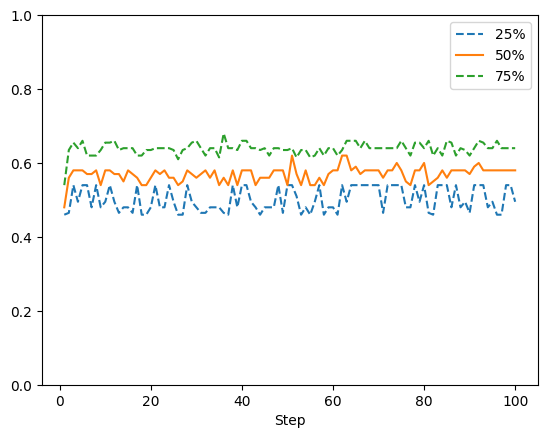

In [20]:
#| fig-align: center
#| fig-cap: "Evolution of Gini coefficient"
#| label: fig-gini-coef
results_df = pd.DataFrame(results)
grp_by_step = results_df.Gini.groupby(results_df.Step).describe()
#grp_by_step.head()

grp_by_step[['25%', '50%', '75%']].plot(style=['--', '-', '--'])
plt.ylim([0, 1]);

We can see from @fig-gini-coef that the Gini index quickly achieves one of the
highest inequality values that we observe in the world, and remains there.

:::

## Agent and Model Classes (v3)

### Adding a spatial component

Next we introduce another critical component of agent-based modeling - the
spatial component. We retain the Gini coefficient computation, but we are going
to modify the model behaviour such that agents only exchange money if the other
agent is nearby. The `MultiGrid` defines a rectangular grid, indexed by `[x,
y]`, where `[0, 0]` is assumed to be at bottom-left and `[width - 1, height -
1]` is the top-right. If a grid is toroidal, the top and bottom, and left and
right, edges wrap to each other.

In the loop to create agents, the agents are added to a random x- and y- cell of
the grid.

In [25]:
class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, N, width, height, rng=None):
        super().__init__(rng=rng)
        self.num_agents = N
        self.grid = mesa.space.MultiGrid(width, height, True)

        # Create agents
        for i in range(self.num_agents):
            a = MoneyAgent(self)
            # Add the agent to a random grid cell
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(a, (x, y))
            
        # Data collectors for the model
        self.datacollector = mesa.DataCollector(
            model_reporters={"Gini": compute_gini}, 
            agent_reporters={"Wealth": "wealth"}
        )

    def step(self):
        self.datacollector.collect(self)
        self.agents.shuffle_do("step")

Now we turn to the agent class. The new version defines methods to `move()` and
to `give_money()`. Within the `move` method, we define that the agent could move
to a neighbouring cell. With mesa, it is possible to define a couple of types of
neighbourhoods: Moore and Von Neumann. In this case, we use the Moore
neighbourghood (see @fig-moore-nbhd).

![](figs/Moore_neighborhood_with_cardinal_directions.png){#fig-moore-nbhd fig-align=center width=30%}

In the `give_money` method, the logic proceeds as follows:

1. Retrieve the agents in neighbouring cells.
2. Remove the agent itself from the list of neighbours, so that an agent will not give money to itself.
3. Choose one of the neighbouring agents at random and give money to it.

In [26]:
class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model):
        super().__init__(model)
        self.wealth = 1

    def move(self):
        possible_steps = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)

    def give_money(self):
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        cellmates.pop(
            cellmates.index(self)
        )  # Ensure agent is not giving money to itself
        if len(cellmates) >= 1:
            other = self.random.choice(cellmates)
            other.wealth += 1
            self.wealth -= 1
                
    # First, the agent moves. Then, it might give money away to another agent 
    # in a neighbouring cell.
    def step(self):
        self.move()
        if self.wealth > 0:
            self.give_money()

### Data Collection

As an example of how the code works, the next code cell runs a *single* iteration
with 100 agents in a 10x10 grid.

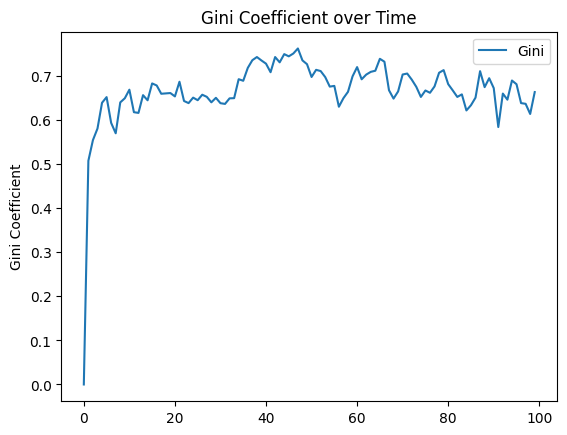

In [27]:
#| fig-align: center
model = MoneyModel(N=100, width=10, height=10, rng=23)
for i in range(100):
    model.step()

gini = model.datacollector.get_model_vars_dataframe()

# Plot the Gini coefficient over time
g = sns.lineplot(data=gini)
g.set(title="Gini Coefficient over Time", ylabel="Gini Coefficient");

::: {#exm-boltzmann-6 style="background-color: #D5D1D164; padding: 20px"}

### Boltzmann model data collection 
\index{Boltzmann Model!v3 spatial}

Now we run the spatial model for 50 iterations.

In [ ]:
params = {"width": 10, "height": 10, "N": range(5, 20, 5)}

results = mesa.batch_run(
    MoneyModel,
    parameters=params,
    iterations=50,
    max_steps=100,
    number_processes=1,
    data_collection_period=1#,
    #display_progress=True,
)

For a visualisation of the results, we shall compute the mean Gini coefficient
at each time step, grouped by `N`.

In [ ]:
#| fig-align: center
#| fig-cap: "Evolution of Gini over time steps"
#| label: fig-gini-over-time-steps

results_df = pd.DataFrame(results)
grp_by_step = results_df.Gini.groupby([results_df.Step, results_df.N]).describe()
grp_by_step.reset_index(inplace=True)

grouped = grp_by_step.groupby('N')
plt.figure(figsize=(10, 6))

for group in grouped:
    plt.plot(group[1]['Step'], group[1]['mean'], label=group[0], alpha=0.5)

plt.xlabel('Step')
plt.ylabel('Gini')
plt.title('Gini vs Step by N (number of agents)');
plt.legend();

In [ ]:

from mesa.visualization import SolaraViz, SpaceRenderer, make_plot_component
from mesa.visualization.components import AgentPortrayalStyle

def agent_portrayal(agent):
    portrayal = AgentPortrayalStyle(size=50, color="tab:orange")
    if agent.wealth == 0:
        portrayal.update(("color", "tab:blue"), ("size", 100))
    return portrayal

model_params = {
    "N": {
        "type": "SliderInt",
        "value": 50,
        "label": "Number of agents:",
        "min": 10,
        "max": 100,
        "step": 1,
    },
    "width": 10,
    "height": 10,
}

money_model = MoneyModel(N=50, width=10, height=10)  # keyword arguments

renderer = (
    SpaceRenderer(model=money_model, backend="matplotlib")
    .setup_agents(agent_portrayal)
    .render()
)

GiniPlot = make_plot_component("Gini", page=0)

page = SolaraViz(
    money_model,
    renderer,
    components=[GiniPlot],
    model_params=model_params,
    name="Boltzmann Wealth Model",
)

# This is required to render the visualization in the Jupyter notebook
page

As we can see from @fig-gini-over-time-steps, the value at which the Gini
coefficient converges to differs for varying `N`. For smaller `N`, the final
Gini value seems to be lower. For all the settings, the convergence does appear
to happen at approximately the same time step.

:::

### Boltzmann Model Final Comments

Remember that simulations are a risk-free approach to trying out different
scenarios. They are especially useful when it is difficult to guage what
interactions the output depends on. In this case, here are some modifications
you can try to understand the Boltzmann Wealth Distribution model better.

* Vary the number of agents, to understand the Gini coefficient after 100 steps.
* When there are N agents, what is the proportion of agents that own 80% of the total wealth after a certain number of steps?
* How can we measure social mobility in this population?
* What if we change the starting income distribution?
* What if we want to know when Gini coefficient first crosses a threshold?
* What if we want to use [Palma Ratio](ttps://en.wikipedia.org/wiki/Income_inequality_metrics#Palma_ratio) instead?

## Simpler Simulation Models

In this section, we provide two examples of "simpler" simulation scenarios.
These are not agent-based models, but they use probability distributions to
model language, and then to represent the scenario where we intend to perform a
2-sample $t$-test.

### N-gram models

Here is an example of how we can simulate from distributions to generate random
(nonsensical) sentences that are "similar" to actual sentences from a text. If your 
code returns an error, you may have to download the `genesis` text first (using
the commented out code).

In [ ]:
#nltk.download('genesis')

kjv = nltk.corpus.genesis.words('english-kjv.txt')
bg = nltk.bigrams(kjv)
cfd = nltk.ConditionalFreqDist(bg)

The object `cfd` contains information on the distribution of words that come
after. For instance, these are the words that come after "she":

In [ ]:
cfd['she']

The object `kjv` contains all the words and punctuations from the King James
Bible. Here are the first 20 words:

In [ ]:
pp = pprint.PrettyPrinter(indent=4, compact=True,)
pp.pprint(' '.join(kjv[:20]))

Next, we extract all bigrams and create a dictionary of frequency distributions.
Each frequency distribution tabulates the occurences of the *next* word.

Suppose we are interested in what words/tokens come after the word 'And' in the bible:

In [ ]:
pp.pprint(cfd['And'].keys())

Thus 'the' is the most likely word after 'And'. The second most likely pairing
would be 'And the', and so on. We can convert this into a pmf, just by
normalising to ensure that it sums to 1. Then we are ready to generate a pairing
once we know that the first word is 'And'. With the second word, we turn to its
frequency distribution and simulate the third word, and so on.

In [ ]:
rng = default_rng(1361)

def generate_model(cfdist, word, num=15):
    for i in range(num):
        print(word, end=' ')
        
        choices = np.array(list(cfdist[word].keys()))
        pp = np.array(list(cfdist[word].values()))
        pp = pp / np.sum(pp)
        word = rng.choice(choices, size=1, p = pp)[0]
        
generate_model(cfd, 'God', 10)

### Power Analysis

Recall that this is the general form of a 2-sample $t$-test:
\begin{eqnarray}
H_0 :& \mu = \mu_0 \\
H_1 :& \mu \neq \mu_0
\end{eqnarray}

Instead of using the $p$-value alone to assess the strength of evidence against the null hypothesis, an alternative method is to specify a significance level and then compare the $p$-value to it. 

This returns the possible four outcomes of a test:

  * $H_0$ was true, but we rejected it (Type I error).
  * $H_0$ was true, and we did not reject it.
  * $H_0$ was false, and we rejected it.
  * $H_0$ was false, but we did not reject it (Type II error).
  
We want the Type I and II errors to be small. 1 minus the Type II error is known
as the power of a test. Typically, we have to specify a particular value of the
parameter in order to compute the power of a test. We cannot simply leave it as
$\mu \neq \mu_0$. These ideas can be used to compute a sample size for an
experiment that we wish to conduct. Let's think about this for a minute.

Suppose we wish to perform some simple A/B testing: we have two groups, and we
wish to be able to detect a difference. What sample size do I need?

The question is actually a little more complex than that. Let's think about what we need to consider:

* How does the true difference affect my sample size?
* How does the variability within each group affect my sample size?
* How does the significance level affect the sample size I need? Recall that the significance level   
  determines my Type I error.

Suppose now, that we fix the significance level to be 5%, with power of at least
0.9 and we are interested in detecting a difference between the means of the
value of 1, when the standard deviation of observed values is 1.2. What sample
size do I need?

::: {#exm-power-1 style="background-color: #D5D1D164; padding: 20px"}

### Power analysis with simulation
\index{Power analysis!simulation}

First, we write a function that will generate two groups of data, and then
computes and returns the decision for a $t$-test.

In [ ]:
def generate_one_sample(alpha, delta_m, sd1, n):
    X = np.random.randn(n)*sd1
    Y = np.random.randn(n)*sd1 + delta_m
    
    ts2 = stats.ttest_ind(X, Y)
    if ts2.pvalue < alpha:
        return 1 # 1 means reject H0
    else:
        return 0

Now we run multiple iterations of that function and plot a graph depicting how the 
rejection probability varies with the sample size.

In [ ]:
#| fig-align: center
#| label: fig-power
#| fig-cap: "Power analysis using simulation"
n_vals = np.arange(5, 50, step=4)

power_est = []
for n_ in n_vals:
    x = [generate_one_sample(0.05, 1, 1.2, n_) for ii in np.arange(0, 2000)]
    power_est.append(np.mean(x))
    # print("Done with sample size " + str(n_))
    
ax = plt.plot(n_vals, power_est, 'go-')
plt.hlines(0.9, n_vals[0], n_vals[-1], colors='b', linestyles='dotted')
plt.title('Power Estimates');

@fig-power shows that we probably need a sample size of approximately 35.

:::

## Summary: Simulation-Based Modeling

In simulation-based modeling, we have several things to consider. 

1. What input distributions should I use?
2. How complicated does my simulation need to be?
3. How do I know it is giving the right results?
4. How many simulations should I run?

Here are some general guidelines to begin with your simulation model:

1. Start simple.
2. Use your own data to decide what distributions should be used.
3. Try with different distributions to see how sensitive your results are to those choices.
4. Add more and more realistic layers to our simulation as you proceed.
5. Remember that simulation is used in estimating mean values. You will be able to estimate standard deviations around your estimate too.

## References

### Mesa Links

1. [Mesa documentation](https://mesa.readthedocs.io/en/stable/index.html): The Boltzmann tutorial in our lecture was modified from this page.
2. [Mesa examples on github](https://github.com/projectmesa/mesa-examples)
3. https://joss.theoj.org/papers/10.21105/joss.07668

### Other ABM Software

1. [Netlogo](https://ccl.northwestern.edu/netlogo/): Netlogo is an  open-source software for ABM. There are a host of examples that you can take a look. However NetLogo uses it's own programming language.
   * https://ccl.northwestern.edu/netlogo/models/index.cgi : Several of the examples can be run directly on the web. The mesa examples repository has several mesa versions of these NetLogo models.
2. [AnyLogic](https://www.anylogic.com/): AnyLogic is a commercial software from a Russian company that combines ABM with DES. It is very powerful and allows for the creation of impressive animations.

### Reference Papers and Websites

1. [Statistical Mechanics of Money, Income, and Wealth: A Short Survey](http://arxiv.org/abs/cond-mat/0211175): This paper contains more information about more complex versions of the Boltzmann model.
2. [Explanation of Boids model](https://cs.stanford.edu/people/eroberts/courses/soco/projects/2008-09/modeling-natural-systems/boids.html)
11. [Hotelling's Law](https://en.wikipedia.org/wiki/Hotelling%27s_law)
12. [Segregation in polygons](https://ncase.me/polygons/)


### Other Simulation Software

1. [Simpy documentation](https://simpy.readthedocs.io/en/latest/) Simpy is a Python package for Discrete Event Simulations (DES). It is appropriate when there are arrivals
   to a set of queues.
2. [Arena](https://www.rockwellautomation.com/en-us/products/software/arena-simulation.html) ARENA is a commercial DES software. There is a free license for academic use.

### Other Links

1. [Python documentation on classes](https://docs.python.org/3.10/tutorial/classes.html)
